# Pseudo-absence Sampling for *Araucaria angustifolia*

This notebook generates pseudo-absence points for *Araucaria angustifolia* within Brazil.

The workflow:
1. reads presence points and the Brazil boundary;
2. removes invalid and duplicated presence locations;
3. creates a 10 km exclusion buffer around presences;
4. randomly samples pseudo-absence points inside Brazil and outside the exclusion area;
5. saves the resulting pseudo-absence dataset as a GeoPackage.

In [40]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

In [41]:
# ============================================================
# 2. FILE PATHS
# ============================================================

# Araucaria presence points.
presence_path = Path(
    "/home/jovyan/grupos/pgrad-disciplinas/"
    "CAP-423-ciencia-de-dados-geoespaciais/dataset//input/"
    "GBIF_Araucaria_angustifolia.gpkg"
)

# Brazil boundary.
brazil_path = Path(
    "/home/jovyan/grupos/pgrad-disciplinas/"
    "CAP-423-ciencia-de-dados-geoespaciais/dataset/input/"
    "brazil.gpkg"
)

# Output pseudo-absence dataset.
output_path = Path(
    "/home/jovyan/grupos/pgrad-disciplinas/"
    "CAP-423-ciencia-de-dados-geoespaciais/dataset/input/"
    "Araucaria_pseudo_absence.gpkg"
)

In [42]:
# ============================================================
# 3. SAMPLING PARAMETERS
# ============================================================

# Minimum distance from presence points, in meters.
buffer_distance = 10_000  # 10 km

# Number of pseudo-absences per presence point.
pseudo_absence_ratio = 1

# Random seed for reproducibility.
random_state = 123

In [43]:
# ============================================================
# 4. READ SPATIAL DATA
# ============================================================

presence = gpd.read_file(presence_path)
brazil = gpd.read_file(brazil_path)

print("Original presence records:", len(presence))
print("Presence CRS:", presence.crs)
print("Brazil CRS:", brazil.crs)

Original presence records: 4648
Presence CRS: EPSG:4326
Brazil CRS: EPSG:4326


In [44]:
# ============================================================
# 5. CLEAN PRESENCE POINTS
# ============================================================

# Remove records without valid geometry.
presence = presence[
    presence.geometry.notna() &
    ~presence.geometry.is_empty
].copy()

# Remove duplicated coordinates.
presence = presence.drop_duplicates(subset="geometry").copy()

print("Unique presence points:", len(presence))

Unique presence points: 3453


In [45]:
# ============================================================
# 6. PROJECT DATA TO A METRIC CRS
# ============================================================

# SIRGAS 2000 / Brazil Polyconic.
# A metric CRS is required to create a buffer in meters.
metric_crs = "EPSG:5880"

presence_metric = presence.to_crs(metric_crs)
brazil_metric = brazil.to_crs(metric_crs)

# Merge all Brazil polygons into a single geometry.
brazil_geometry = brazil_metric.geometry.union_all()

In [46]:
# ============================================================
# 7. DEFINE THE AVAILABLE SAMPLING AREA
# ============================================================

# Create exclusion buffers around all presence points.
presence_buffer = presence_metric.geometry.buffer(
    buffer_distance
).union_all()

# Remove buffered presence areas from Brazil.
available_area = brazil_geometry.difference(presence_buffer)

print(
    f"Minimum distance from presences: "
    f"{buffer_distance / 1000:.1f} km"
)

Minimum distance from presences: 10.0 km


In [47]:
# ============================================================
# 8. DEFINE NUMBER OF PSEUDO-ABSENCES
# ============================================================

n_presence = len(presence_metric)
n_pseudo_absence = int(n_presence * pseudo_absence_ratio)

print("Presence points:", n_presence)
print("Pseudo-absence points:", n_pseudo_absence)

Presence points: 3453
Pseudo-absence points: 3453


In [48]:
# ============================================================
# 9. GENERATE RANDOM PSEUDO-ABSENCE POINTS
# ============================================================

rng = np.random.default_rng(random_state)

minx, miny, maxx, maxy = available_area.bounds
pseudo_points = []

while len(pseudo_points) < n_pseudo_absence:
    remaining = n_pseudo_absence - len(pseudo_points)
    batch_size = max(remaining * 3, 1000)

    x = rng.uniform(minx, maxx, batch_size)
    y = rng.uniform(miny, maxy, batch_size)

    candidates = gpd.GeoSeries(
        [Point(xi, yi) for xi, yi in zip(x, y)],
        crs=metric_crs
    )

    valid = candidates[candidates.within(available_area)]
    pseudo_points.extend(valid.tolist())

# Keep exactly the requested number of points.
pseudo_points = pseudo_points[:n_pseudo_absence]

In [49]:
# ============================================================
# 10. CREATE PRESENCE AND PSEUDO-ABSENCE DATASET
# ============================================================

# Create the pseudo-absence GeoDataFrame.
pseudo_absence = gpd.GeoDataFrame(
    {
        "presence": [0] * len(pseudo_points)
    },
    geometry=pseudo_points,
    crs=metric_crs
)

# Return pseudo-absences to the original CRS.
pseudo_absence = pseudo_absence.to_crs(presence.crs)

# Keep only the geometry from the original occurrence dataset.
presence_points = presence[["geometry"]].copy()

# Assign class 1 to occurrence points.
presence_points["presence"] = 1

# Combine occurrences and pseudo-absences.
samples = gpd.GeoDataFrame(
    pd.concat(
        [presence_points, pseudo_absence],
        ignore_index=True
    ),
    geometry="geometry",
    crs=presence.crs
)

# Create a unique sample ID.
samples["id"] = np.arange(1, len(samples) + 1)

# Reorder columns.
samples = samples[
    ["id", "presence", "geometry"]
]

# Check the final dataset.
print("Occurrences:", (samples["presence"] == 1).sum())
print("Pseudo-absences:", (samples["presence"] == 0).sum())
print("Total samples:", len(samples))

samples.head()

Occurrences: 3453
Pseudo-absences: 3453
Total samples: 6906


,id,presence,geometry
0,1,1,POINT (-49.61149 -28.06746)
1,2,1,POINT (-49.96145 -28.28208)
2,3,1,POINT (-52.27105 -29.39495)
3,4,1,POINT (-48.97911 -25.38728)
4,5,1,POINT (-53.03313 -24.19717)


In [50]:
# ============================================================
# 11. SAVE THE PSEUDO-ABSENCE DATASET
# ============================================================

samples.to_file(
    output_path,
    driver="GPKG"
)

print(f"Presence/pseudo-absence dataset saved to:\n{output_path}")

Presence/pseudo-absence dataset saved to:
/home/jovyan/grupos/pgrad-disciplinas/CAP-423-ciencia-de-dados-geoespaciais/dataset/input/Araucaria_pseudo_absence.gpkg


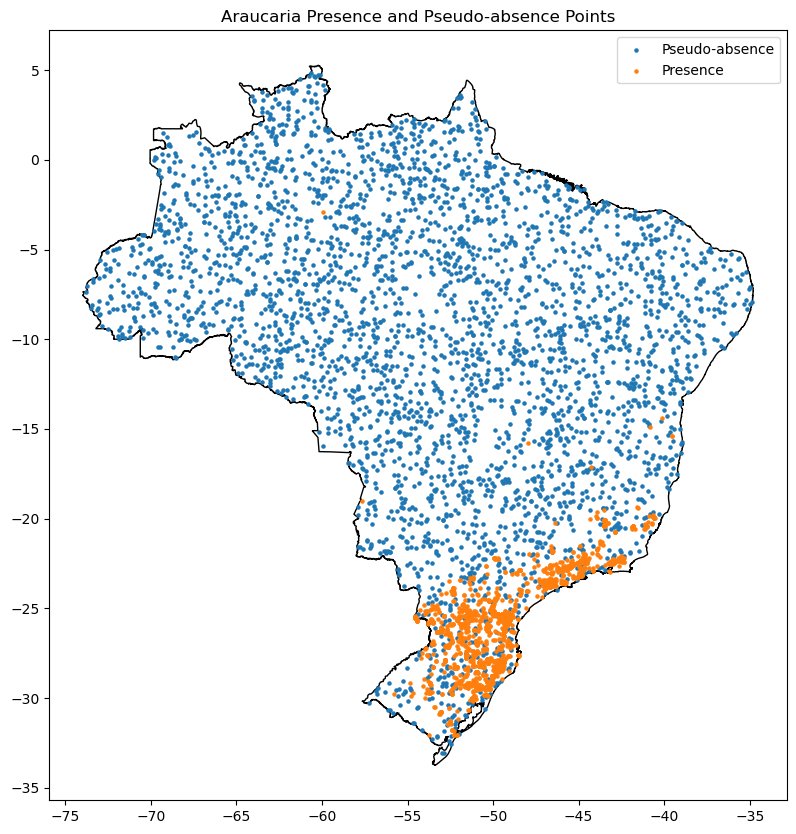

In [52]:
# ============================================================
# 12. VISUAL CHECK
# ============================================================

# Read the combined presence/pseudo-absence dataset.
samples = gpd.read_file(output_path)

# Reproject Brazil boundary to the same CRS.
brazil_plot = brazil.to_crs(samples.crs)

# Separate classes only for visualization.
presence_plot = samples[samples["presence"] == 1]
pseudo_absence_plot = samples[samples["presence"] == 0]

# Plot Brazil boundary.
ax = brazil_plot.plot(
    figsize=(10, 10),
    facecolor="none",
    edgecolor="black"
)

# Plot pseudo-absence points.
pseudo_absence_plot.plot(
    ax=ax,
    markersize=5,
    label="Pseudo-absence"
)

# Plot presence points.
presence_plot.plot(
    ax=ax,
    markersize=5,
    label="Presence"
)

plt.legend()
plt.title("Araucaria Presence and Pseudo-absence Points")
plt.show()